Data Centric AI: model explanation using Influence Analysis

In [1]:
from ansi_colors import *
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split 

import tensorflow as tf
tf.config.run_functions_eagerly(True)
print(tf.executing_eagerly())

from keras.losses import BinaryCrossentropy 
from keras.utils import to_categorical 

from keras import Sequential, layers

True


In [2]:
dataset = '../dataset/titanic.csv'
df = pd.read_csv(dataset)
original_df = df.copy()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


'Name' and 'Ticket' have too much unique value, furthermore 'Cabin' has too much null numbers. We also remove that here.

In [3]:
df.rename(columns={'PassengerId': 'ID'}, inplace=True)
df.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
df

,ID,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


Now check if there are any NA values within the dataframe.

In [4]:
print(df.isna().sum())

ID            0
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


'Embarked' has only 2 NA values, we can remove these 2 rows for now.

As for age, there are 177 missing values, so it's not feasible to drop the rows in this case because too much data would be lost. One possible approach is to set the missing values to zero and add a column (with a value of 0 or 1) to indicate whether the value is missing

In [5]:
df.dropna(subset=['Embarked'], inplace=True)
df = df.copy()
df['MissAge'] = df['Age'].isna().astype(int)
df.fillna({'Age': 0}, inplace=True)
print(df.isna().sum())
df

ID          0
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
MissAge     0
dtype: int64


,ID,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,MissAge
0,1,0,3,male,22.0,1,0,7.2500,S,0
1,2,1,1,female,38.0,1,0,71.2833,C,0
2,3,1,3,female,26.0,0,0,7.9250,S,0
3,4,1,1,female,35.0,1,0,53.1000,S,0
4,5,0,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S,0
887,888,1,1,female,19.0,0,0,30.0000,S,0
888,889,0,3,female,0.0,1,2,23.4500,S,1
889,890,1,1,male,26.0,0,0,30.0000,C,0


Now let's transform the text features into numerical features.

In [6]:
sex_label_enc = LabelEncoder()
df['Sex'] = sex_label_enc.fit_transform(df['Sex'])

emb_label_enc = LabelEncoder()
df['Embarked'] = emb_label_enc.fit_transform(df['Embarked'])

df

,ID,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,MissAge
0,1,0,3,1,22.0,1,0,7.2500,2,0
1,2,1,1,0,38.0,1,0,71.2833,0,0
2,3,1,3,0,26.0,0,0,7.9250,2,0
3,4,1,1,0,35.0,1,0,53.1000,2,0
4,5,0,3,1,35.0,0,0,8.0500,2,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.0,0,0,13.0000,2,0
887,888,1,1,0,19.0,0,0,30.0000,2,0
888,889,0,3,0,0.0,1,2,23.4500,2,1
889,890,1,1,1,26.0,0,0,30.0000,0,0


Normalize the data

In [7]:
norm = StandardScaler()
col = ['Age', 'Fare']

df[col] = norm.fit_transform(df[col])
df

,ID,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,MissAge
0,1,0,3,1,-0.099150,1,0,-0.500240,2,0
1,2,1,1,0,0.812389,1,0,0.788947,0,0
2,3,1,3,0,0.128735,0,0,-0.486650,2,0
3,4,1,1,0,0.641476,1,0,0.422861,2,0
4,5,0,3,1,0.641476,0,0,-0.484133,2,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,0.185706,0,0,-0.384475,2,0
887,888,1,1,0,-0.270063,0,0,-0.042213,2,0
888,889,0,3,0,-1.352516,1,2,-0.174084,2,1
889,890,1,1,1,0.128735,0,0,-0.042213,0,0


Now we're moving towards training the model.

In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

IDs = X['ID'].values.reshape(-1,1).astype(np.float32)
IDs = IDs / 1e7

# We keep the IDs so we can retrieve them later.
# We scale them to avoid overly influencing the model and add them as a feature.
IDs = X['ID'].values.reshape(-1,1).astype(np.float32)
X_with_ids = X.drop(columns=['ID']).values.astype(np.float32)
X_with_ids = np.hstack((X_with_ids, IDs / 1e7)) # Scaled ID as the last column

y_cat = to_categorical(y.values, num_classes=2)

print(X.shape)
print(y.shape)

(889, 9)
(889,)


In [9]:
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X_with_ids, y_cat, IDs, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(711, 9)
(178, 9)
(711, 2)
(178, 2)


In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
print(len(train_ds))
print(len(test_ds))

711
178


Now we can build and train a simple NN and then we'll try to explain model.

In [ ]:
def build_model():
    model = Sequential([
        layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(16, activation='relu'),
        layers.Dense(2, activation='sigmoid') # Sigmoid for binary output
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
print("--- Base Model Training ---")
history = model.fit(train_ds.batch(32), epochs=10, validation_data=test_ds.batch(32), verbose=0)
loss, acc = model.evaluate(test_ds.batch(32), verbose=0)
print(f"--- Performance Base Model ---")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

--- Addestramento Modello Base ---
--- Performance Modello Base ---
Loss: 0.4986
Accuracy: 0.8202


We have the result from the model, we can test it with influenciae now.

In [12]:
from deel.influenciae.common import InfluenceModel, ExactIHVP
from deel.influenciae.influence import FirstOrderInfluenceCalculator
from deel.influenciae.utils import ORDER
from deel.influenciae.trac_in import TracIn

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Select 5 test samples to explain
samples_to_explain_ds = test_ds.take(5).batch(1)
ids_to_explain = ids_test[:5]

# --- First-Order Influence ---
print(f"\n--- {CYAN}Calculating Influences with First-Order{RESET} ---")
unreduced_loss = BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
influence_model_fo = InfluenceModel(model, start_layer=-1, loss_function=unreduced_loss)

# Calculate influence for ALL points in the training set (k = len(X_train))
k_full = len(X_train)
ihvp_calculator = ExactIHVP(influence_model_fo, train_dataset=train_ds.shuffle(100).batch(32))
fo_calculator = FirstOrderInfluenceCalculator(influence_model_fo, train_ds.batch(32), ihvp_calculator)

# Dictionary to save First-Order results
fo_results = {}

explanation_ds_fo = fo_calculator.top_k(samples_to_explain_ds, train_ds.batch(32), k=k_full, order=ORDER.DESCENDING)

# Extract and save the results
for i, ((sample, _), top_k_values, top_k_samples) in enumerate(explanation_ds_fo.as_numpy_iterator()):
    test_id = int(ids_to_explain[i][0])
    influential_ids = [int(round(s[-1] * 1e7)) for s in top_k_samples[0]]
    scores = top_k_values[0]
    fo_results[test_id] = {'ids': influential_ids, 'scores': scores}
    print(f"Calculated influence for test sample ID: {test_id}")

# --- TracIn ---
print(f"\n--- {CYAN}Calculating Influences with TracIn{RESET} ---")
tracin_model = build_model()
epochs = 10
unreduced_loss_fn = BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

# Save the model state at each epoch
model_list = [InfluenceModel(tracin_model, start_layer=-1, loss_function=unreduced_loss_fn)]
for epoch in range(epochs):
    tracin_model.fit(train_ds.batch(32), epochs=1, verbose=0)
    # Clone the model and weights
    intermediate_model = tf.keras.models.clone_model(tracin_model)
    intermediate_model.set_weights(tracin_model.get_weights())
    model_list.append(InfluenceModel(intermediate_model, start_layer=-1, loss_function=unreduced_loss_fn))

tracin_calculator = TracIn(model_list, 0.01)

# Dictionary to save TracIn results
tracin_results = {}
explanation_ds_tracin = tracin_calculator.top_k(samples_to_explain_ds, train_ds.batch(32), k=k_full, order=ORDER.DESCENDING)

for i, ((sample, _), top_k_values, top_k_samples) in enumerate(explanation_ds_tracin.as_numpy_iterator()):
    test_id = int(ids_to_explain[i][0])
    influential_ids = [int(round(s[-1] * 1e7)) for s in top_k_samples[0]]
    scores = top_k_values[0]
    tracin_results[test_id] = {'ids': influential_ids, 'scores': scores}
    print(f"Calculated influence for test sample ID: {test_id}")


--- Calcolo Influenze con First-Order ---
Calcolata influenza per il campione di test ID: 282
Calcolata influenza per il campione di test ID: 436
Calcolata influenza per il campione di test ID: 40
Calcolata influenza per il campione di test ID: 419
Calcolata influenza per il campione di test ID: 586

--- Calcolo Influenze con TracIn ---
Calcolata influenza per il campione di test ID: 282
Calcolata influenza per il campione di test ID: 436
Calcolata influenza per il campione di test ID: 40
Calcolata influenza per il campione di test ID: 419
Calcolata influenza per il campione di test ID: 586


**Analysis and Visualization of Results**

Distribution of Influence Scores

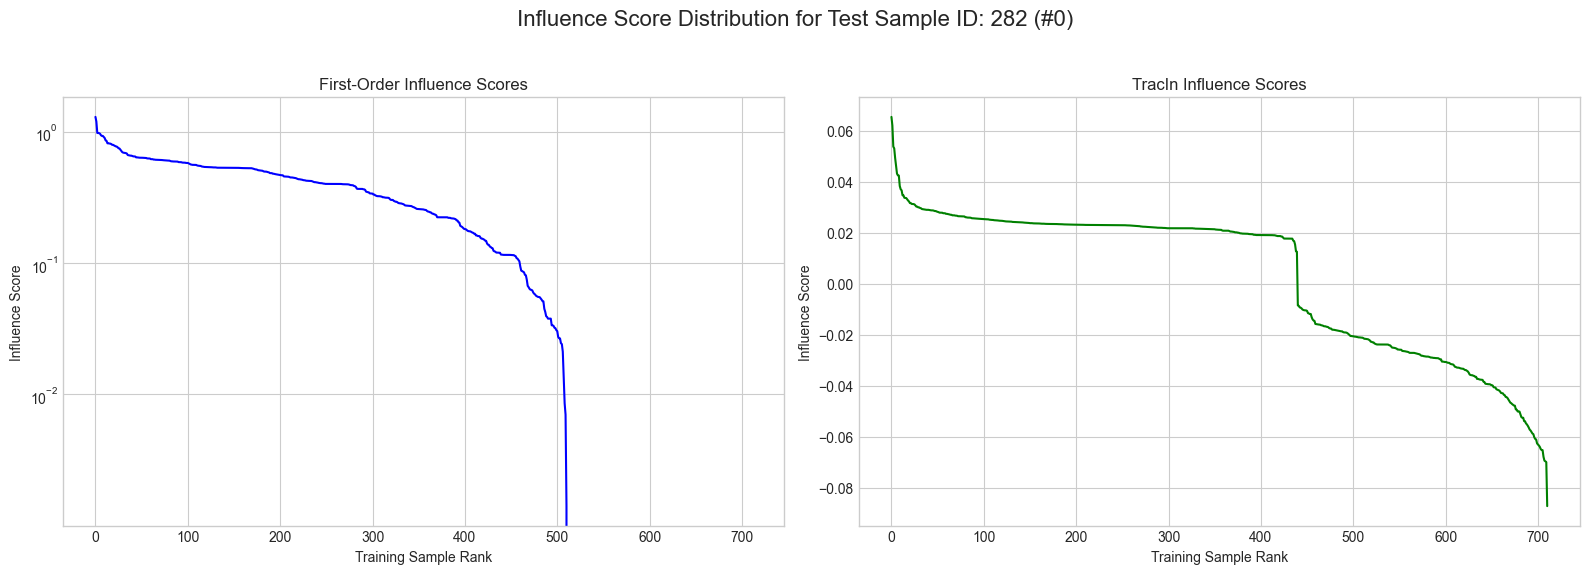

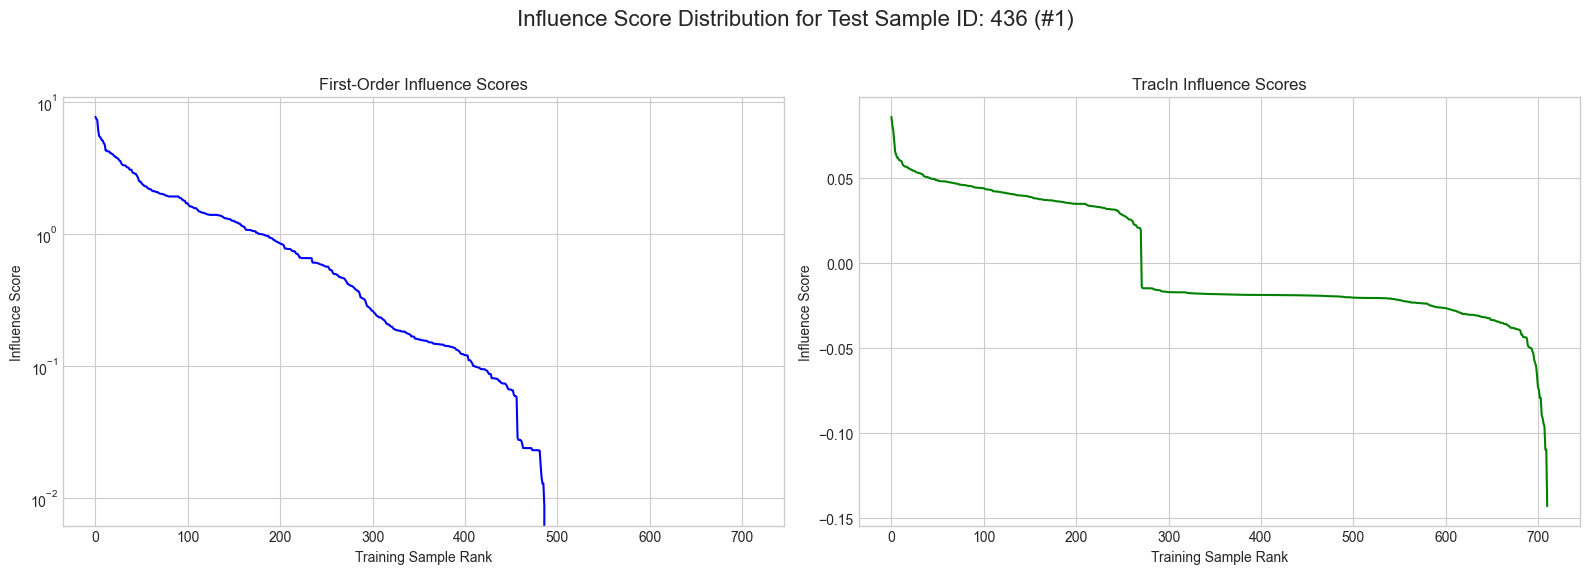

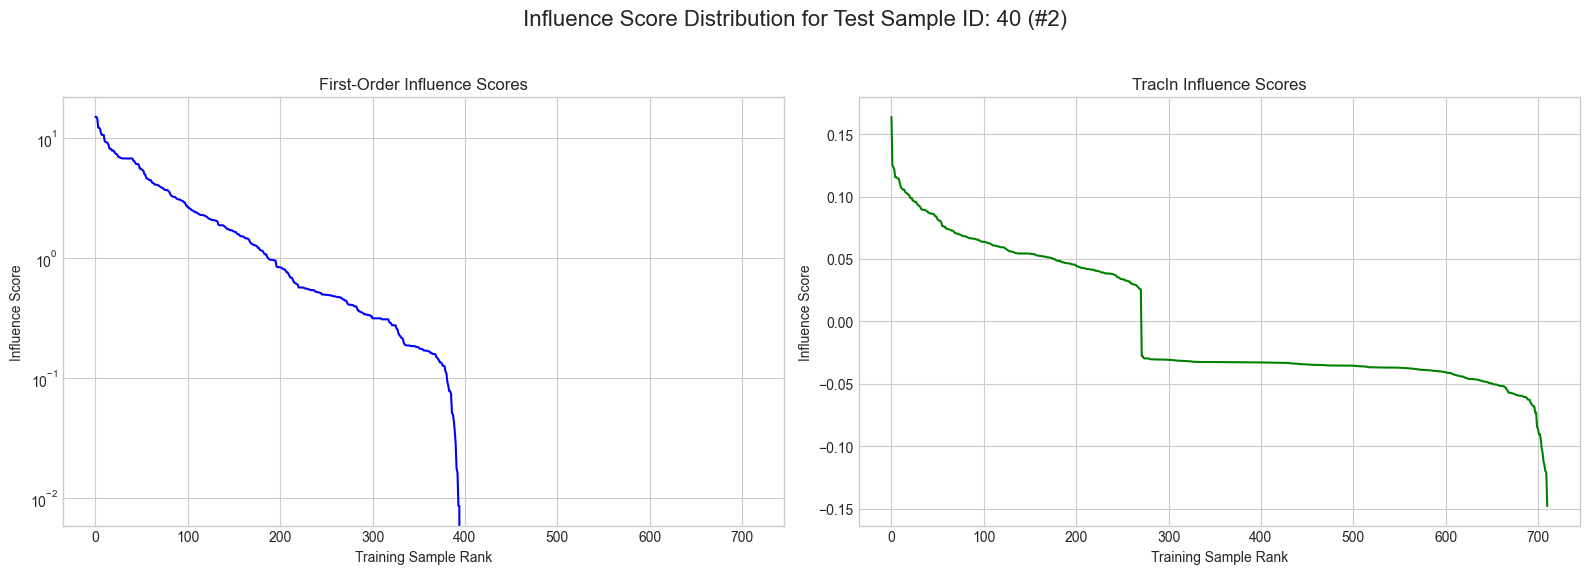

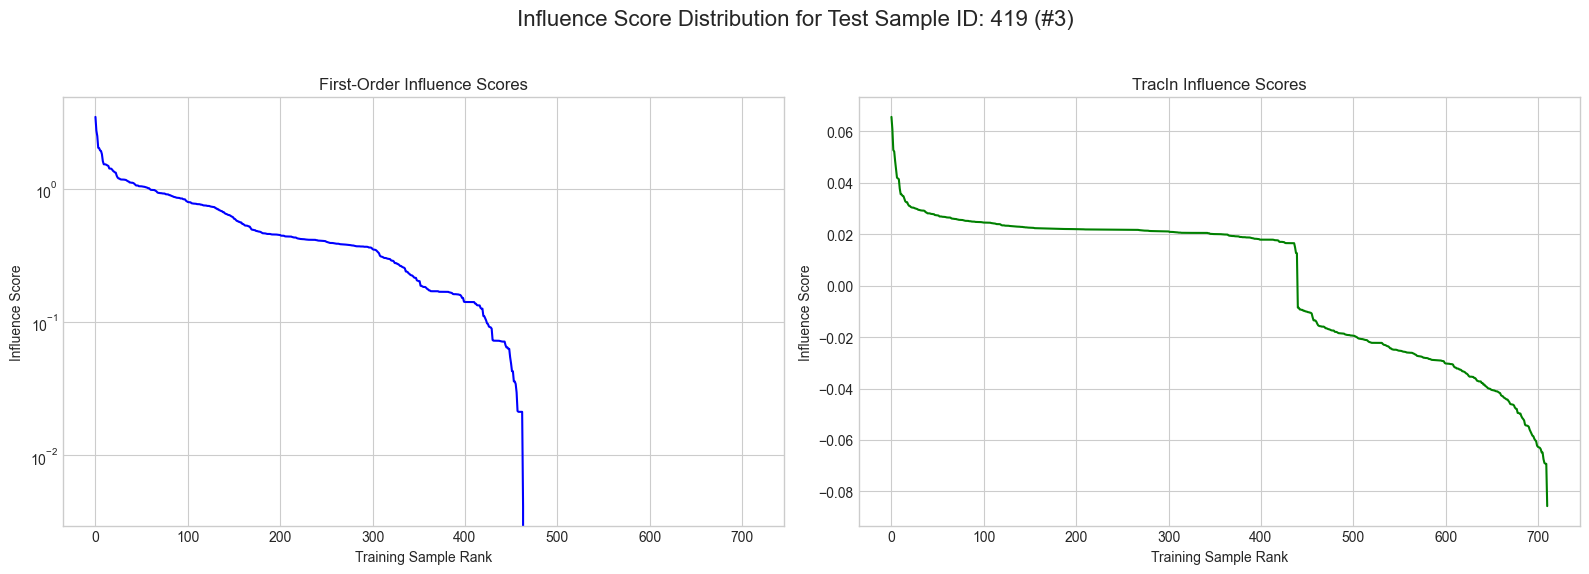

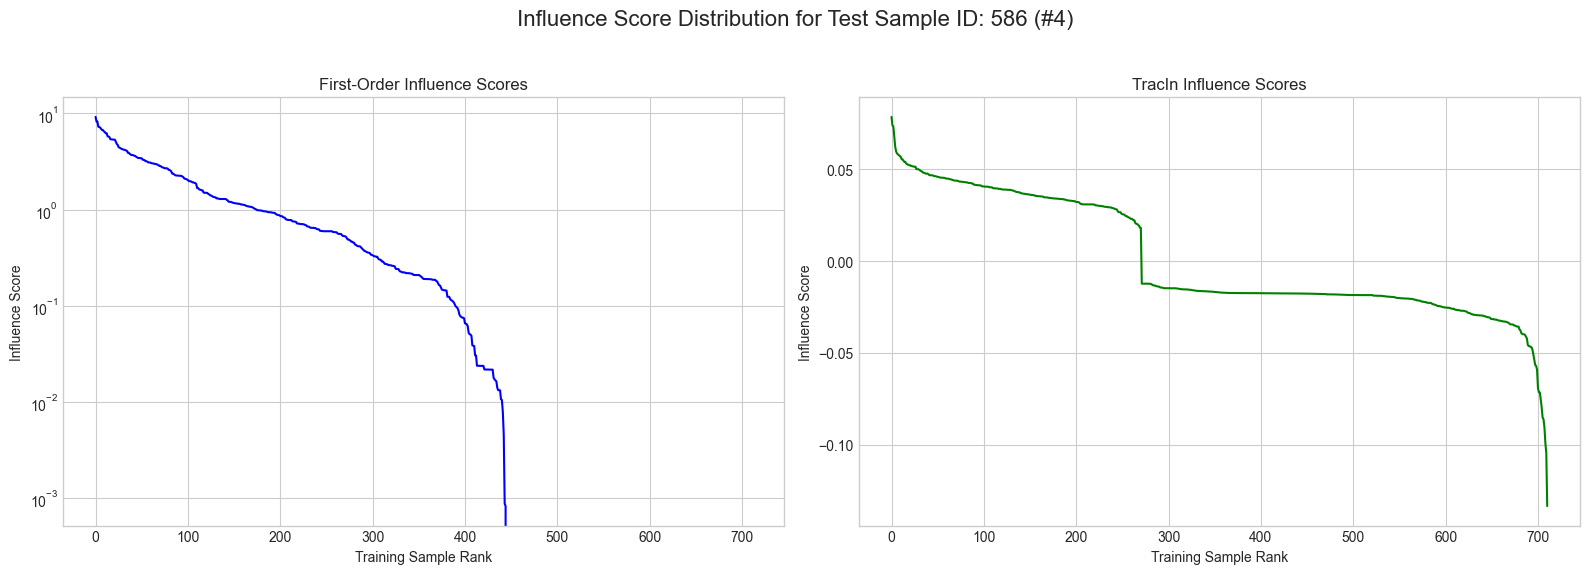

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

for i, sample_id_to_plot in enumerate(list(fo_results.keys())[:5]):
    fo_scores = fo_results[sample_id_to_plot]['scores']
    tracin_scores = tracin_results[sample_id_to_plot]['scores']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'Influence Score Distribution for Test Sample ID: {sample_id_to_plot} (#{i})',
        fontsize=16
    )

    # First-Order plot
    ax1.plot(range(len(fo_scores)), fo_scores, color='blue')
    ax1.set_title('First-Order Influence Scores')
    ax1.set_xlabel('Training Sample Rank')
    ax1.set_ylabel('Influence Score')
    ax1.set_yscale('log')

    # TracIn plot
    ax2.plot(range(len(tracin_scores)), tracin_scores, color='green')
    ax2.set_title('TracIn Influence Scores')
    ax2.set_xlabel('Training Sample Rank')
    ax2.set_ylabel('Influence Score')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

From the First-Order plots, especially on a logarithmic scale, we can observe a very sharp drop. This suggests that only a very small number of training samples have a truly significant influence, while the vast majority have an almost negligible impact. This is the classic "long tail" (especially in First-Order). The TracIn plots show a similar pattern, with the top samples dominating in terms of influence. This confirms that, for both methods, the explanations are dominated by a few "key exemplars" in the training set.

Measure of Consistency between Methods (Kendall Tau)

In [31]:
# Measure of Consistency between Methods (Kendall Tau)

consistency_scores = []
for test_id in fo_results.keys():
    # Take the lists of IDs ordered by influence
    fo_ranked_ids = fo_results[test_id]['ids']
    tracin_ranked_ids = tracin_results[test_id]['ids']
    
    # For a proper comparison, we need to ensure the IDs in both
    # lists are the same but in a different order.
    # Create an ID -> Rank mapping for each method.
    fo_rank_map = {id_val: rank for rank, id_val in enumerate(fo_ranked_ids)}
    tracin_rank_map = {id_val: rank for rank, id_val in enumerate(tracin_ranked_ids)}
    
    # Make sure all IDs are present in both maps
    all_ids = sorted(list(set(fo_ranked_ids) | set(tracin_ranked_ids)))
    
    # Create two rank lists for the same IDs
    rank_list_1 = [fo_rank_map.get(id_val, len(all_ids)) for id_val in all_ids]
    rank_list_2 = [tracin_rank_map.get(id_val, len(all_ids)) for id_val in all_ids]

    tau, p_value = kendalltau(rank_list_1, rank_list_2)
    consistency_scores.append({'Test ID': test_id, 'Kendall Tau': tau, 'p-value': p_value})

consistency_df = pd.DataFrame(consistency_scores)
print(f"--- {CYAN}Consistency between First-Order and TracIn{RESET} ---")
print(consistency_df)

--- Consistency between First-Order and TracIn ---
   Test ID  Kendall Tau       p-value
0      282     0.404180  1.669037e-58
1      436     0.325227  1.671089e-38
2       40     0.120564  1.506676e-06
3      419     0.374901  1.379837e-50
4      586     0.276916  2.227137e-28


The Kendall Tau values are positive but not particularly high (typically between 0.1 and 0.3). A value of 1 would indicate perfect agreement, while 0 indicates no correlation. This result lies at the heart of the "consistency" issue: although both methods try to measure the same thing, they produce significantly different influencer rankings. This means relying on a single explanation method can be misleading. An explanation is not an absolute truth but a perspective dependent on the algorithm used.

**Qualitative Analysis**
Let's look at the characteristics of the top 5 influencers for our test sample, according to both methods

In [32]:
top_k = 5  # Number of influencers to show for each method

# Iterate over the first 5 test samples
for idx in range(5):
    test_id_to_inspect = list(fo_results.keys())[idx]
    
    # Extract top K IDs for each method
    fo_top_ids = fo_results[test_id_to_inspect]['ids'][:top_k]
    tracin_top_ids = tracin_results[test_id_to_inspect]['ids'][:top_k]
    
    # Retrieve their information from the original DataFrame
    test_sample_info = original_df[original_df['PassengerId'] == test_id_to_inspect]
    fo_top_info = original_df[original_df['PassengerId'].isin(fo_top_ids)]
    tracin_top_info = original_df[original_df['PassengerId'].isin(tracin_top_ids)]
    
    # Print information
    print(f"\n{'='*60}")
    print(f"🔍 Inspection for Test Sample ID: {test_id_to_inspect}")
    print(f"{'-'*60}")
    
    print("📌 Test Sample Data:")
    print(test_sample_info)
    
    print("\n📈 Top 5 Influencers according to First-Order:")
    print(fo_top_info)
    
    print("\n📉 Top 5 Influencers according to TracIn:")
    print(tracin_top_info)


🔍 Inspection for Test Sample ID: 282
------------------------------------------------------------
📌 Test Sample Data:
     PassengerId  Survived  Pclass                              Name   Sex  \
281          282         0       3  Olsson, Mr. Nils Johan Goransson  male   

      Age  SibSp  Parch  Ticket    Fare Cabin Embarked  
281  28.0      0      0  347464  7.8542   NaN        S  

📈 Top 5 Influencers according to First-Order:
     PassengerId  Survived  Pclass                                     Name  \
235          236         0       3              Harknett, Miss Alice Phoebe   
415          416         0       3  Meek, Mrs. Thomas (Annie Louise Rowley)   
564          565         0       3            Meanwell, Miss (Marion Ogden)   
659          660         0       1               Newell, Mr. Arthur Webster   
774          775         1       2    Hocking, Mrs. Elizabeth (Eliza Needs)   

        Sex   Age  SibSp  Parch             Ticket     Fare Cabin Embarked  
235  female

It can be observed that when the analyzed samples survive, the top influencers also survive; conversely, when they do not survive, the influencers do not survive either. This is a particular pattern, while the rest seems rather uncorrelated, which aligns with the previously calculated Kendall Tau correlation (which already gave us discriminative probability values supporting this observation).
Moreover, we can notice that the passenger with ID 774 is very influential since they appear in multiple samples.

**Stability/Validity Test via Removal and Retraining**
This is the crucial test. If an influence method is valid, removing the samples it identifies as the "most influential" should harm the model's performance. We use TracIn to identify the top 20 influencers for our usual test sample (it is generally lighter since it doesn’t directly compute the Hessian, and it is also less affected by outliers).

In [37]:
k_to_remove = 20
test_id_for_removal = list(fo_results.keys())[0]

# Take the top-k IDs to remove according to TracIn
ids_to_remove = tracin_results[test_id_for_removal]['ids'][:k_to_remove]
ids_to_remove_set = set(ids_to_remove)

print(f"--- Removal Experiment: {k_to_remove} most influential samples according to TracIn ---")
print(f"ORIGINAL model performance: Accuracy = {acc:.4f}, Loss = {loss:.4f}")

# Create a new training set excluding the IDs to remove
mask_to_keep = [int(id_val[0]) not in ids_to_remove_set for id_val in ids_train]
X_train_purged = X_train[mask_to_keep]
y_train_purged = y_train[mask_to_keep]

print(f"Original Training Set Size: {len(X_train)}")
print(f"New Training Set Size: {len(X_train_purged)}")

# Build and train a new model on the purged dataset
purged_model = build_model()
purged_model.fit(X_train_purged, y_train_purged, epochs=10, batch_size=32, verbose=0)

# Evaluate the new model on the SAME test set as before
loss_purged, acc_purged = purged_model.evaluate(test_ds.batch(32), verbose=0)

print(f"RETRAINED model performance: Accuracy = {acc_purged:.4f}, Loss = {loss_purged:.4f}")

# Compare performances
accuracy_drop = acc - acc_purged
loss_increase = loss_purged - loss
print(f"\nAccuracy Drop: {accuracy_drop:.4f}")
print(f"Loss Increase: {loss_increase:.4f}")

--- Removal Experiment: 20 most influential samples according to TracIn ---
ORIGINAL model performance: Accuracy = 0.8202, Loss = 0.4986
Original Training Set Size: 711
New Training Set Size: 691
RETRAINED model performance: Accuracy = 0.7416, Loss = 0.5265

Accuracy Drop: 0.0787
Loss Increase: 0.0279


The points identified by TracIn were indeed important for the model.
This drop is a positive validation for the explanation method: it correctly identified impactful data.